# Projekt: Zaawansowana Analiza i Predykcja Rotacji Pracowników (Employee Attrition)
## Część Analityczna

---

### 1. Wybór i uzasadnienie zestawu danych

* **Zestaw danych:** IBM HR Analytics Employee Attrition & Performance (`WA_Fn-UseC_-HR-Employee-Attrition.csv`).
* **Adekwatność do problemu biznesowego:** Zbiór zawiera szczegółowe dane o 3000 pracownikach opisane za pomocą 35 cech. Obejmują one profil demograficzny, satysfakcję ze środowiska pracy, poziom wynagrodzeń, historię zatrudnienia oraz kluczową zmienną docelową – informację o odejściu z firmy (`Attrition`). Jest to klasyczne, a zarazem krytyczne zagadnienie z obszaru *People Analytics / HR Tech*, ukierunkowane na identyfikację predyktorów ryzyka odejścia pracowników i minimalizację kosztów rekrutacji oraz retencji talentów.
* **Zastosowanie metod sztucznej inteligencji (AI):** 1. **Uczenie nadzorowane:** Problem redukuje się do klasyfikacji binarnej, gdzie model uczy się przewidywać wartość zmiennej docelowej `Attrition` (`Yes` / `No`).
    2. **Porównanie algorytmów:** Dane pozwalają na wdrożenie i walidację szerokiego spektrum klasyfikatorów – od modeli liniowych po zaawansowane algorytmy zespołowe.
    3. **Wyjaśnialność modeli (XAI):** Struktura zbioru umożliwia przeprowadzenie analizy ważności cech (*Feature Importance*), co ma fundamentalne znaczenie dla podejmowania strategicznych decyzji zarządczych.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, f1_score, precision_recall_curve
)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[INFO] XGBoost niedostępny – zastąpiony GradientBoostingClassifier")

import warnings
warnings.filterwarnings('ignore')

url = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)
print(f"Pomyślnie załadowano zbiór danych. Kształt macierzy: {df.shape}")


Pomyślnie załadowano zbiór danych. Kształt macierzy: (1470, 35)


### 2. Analiza eksploracyjna zbioru danych (EDA)

W ramach wstępnego etapu analizy danych (Exploratory Data Analysis) przeprowadzimy audyt struktury technicznej zbioru, dokonamy ewaluacji rozkładów statystycznych, zidentyfikujemy anomalie (w tym kolumny bezwartościowe informacyjnie) oraz zbadamy korelacje między cechami a skłonnością do rotacji.

#### 2.1 Struktura techniczna danych oraz typy zmiennych
W pierwszej kolejności weryfikujemy kształt macierzy danych, nazewnictwo kolumn oraz przypisane im typy danych (numeryczne `int64` oraz kategoryczne/tekstowe `object` lub `str`).

In [2]:
print("--- STRUKTURA TECHNICZNA I TYPY ZMIENNYCH ---")
df.info()

--- STRUKTURA TECHNICZNA I TYPY ZMIENNYCH ---
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLe

#### 2.2 Weryfikacja kompletności danych (Missing Values Audit)
Przed przystąpieniem do modelowania matematycznego konieczne jest sprawdzenie występowania braków w danych (`NaN` / `Null`). Brakujące wartości mogłyby zaburzyć proces uczenia algorytmów lub wymagać zastosowania metod imputacji (np. średnią, medianą lub modelem KNN).Sprawdzenie braków w danych bezpośrednio

In [3]:
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"Całkowita liczba brakujących wartości w zbiorze: {total_missing}")
if total_missing > 0:
    print(missing_values[missing_values > 0])

Całkowita liczba brakujących wartości w zbiorze: 0


#### 2.3 Opis statystyczny cech numerycznych
Generujemy podstawowe miary tendencji centralnej oraz dyspersji (średnia, odchylenie standardowe, kwartyle, wartości ekstremalne) dla cech ilościowych. Pozwala to na wstępne wykrycie potencjalnych wartości odstających (*outliers*) oraz ocenę skali i zakresów zmiennych, co jest kluczowe dla modeli wrażliwych na rozpiętość cech.

In [4]:
print("--- OPIS STATYSTYCZNY CECH NUMERYCZNYCH ---")
display(df.describe().T)

--- OPIS STATYSTYCZNY CECH NUMERYCZNYCH ---


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


#### 2.2 Identyfikacja kolumn stałych
Niektóre kolumny mogą nie wnosić żadnej informacji, jeśli mają stałą wartość dla wszystkich rekordów.

In [5]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Kolumny stałe (do usunięcia w etapie modelowania): {constant_cols}")

Kolumny stałe (do usunięcia w etapie modelowania): ['EmployeeCount', 'Over18', 'StandardHours']


#### 2.4 Identyfikacja i eliminacja cech stałych (Zero-Variance Features)
Cechy, które przyjmują dokładnie jedną, stałą wartość dla każdego rekordu w bazie danych, posiadają zerową wariancję. Z punktu widzenia uczenia maszynowego nie wnoszą one żadnej wartości predykcyjnej (nie różnicują próbek), a zwiększają wymiarowość zbioru. Należy je zidentyfikować w celu późniejszego usunięcia w potoku przetwarzania.

In [6]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Zidentyfikowane cechy stałe (zerowa wariancja): {constant_cols}")

Zidentyfikowane cechy stałe (zerowa wariancja): ['EmployeeCount', 'Over18', 'StandardHours']


#### 2.5 Analiza korelacji liniowej zmiennych ze zmienną docelową
Aby zbadać liniową zależność zmiennych numerycznych ze skłonnością do odejścia, transformujemy zmienną docelową `Attrition` oraz kluczową zmienną kategoryczną `OverTime` na postać binarną (0/1). Następnie wyznaczamy współczynniki korelacji Pearsona, co pozwoli wyłonić najsilniejsze, potencjalne predyktory rotacji.

In [7]:
df_numeric_analysis = df.copy()
df_numeric_analysis['Attrition_numeric'] = df_numeric_analysis['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df_numeric_analysis['OverTime_numeric'] = df_numeric_analysis['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

numeric_cols = df_numeric_analysis.select_dtypes(include=[np.number]).columns
correlations = df_numeric_analysis[numeric_cols].corr()['Attrition_numeric'].sort_values(ascending=False)

print("--- KORELACJA ZMIENNYCH ZE ZMIENNĄ DOCELOWĄ (Attrition) ---")
print(correlations)

--- KORELACJA ZMIENNYCH ZE ZMIENNĄ DOCELOWĄ (Attrition) ---
Attrition_numeric           1.000000
OverTime_numeric            0.246118
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYea

#### 2.6 Zaawansowana wizualizacja i interpretacja dystrybucji danych

Kluczowym elementem EDA jest graficzne przedstawienie zachowań danych. Przeprowadzimy wizualizację dwóch podstawowych obszarów:
1. **Rozkład zmiennej docelowej (`Attrition`):** Ocena zbalansowania klas w zbiorze. Nierównomierny rozkład (dysproporcja między klasą `No` a `Yes`) zasygnalizuje konieczność użycia odpowiednich metryk (np. F1-score, Recall) zamiast ogólnego Accuracy oraz zastosowania stratyfikacji przy podziale danych.
2. **Macierz korelacji:** Analiza współliniowości (*Multicollinearity*) między cechami, która pozwoli wykryć zmienne silnie ze sobą sprzężone (np. poziom stanowiska a miesięczny dochód).

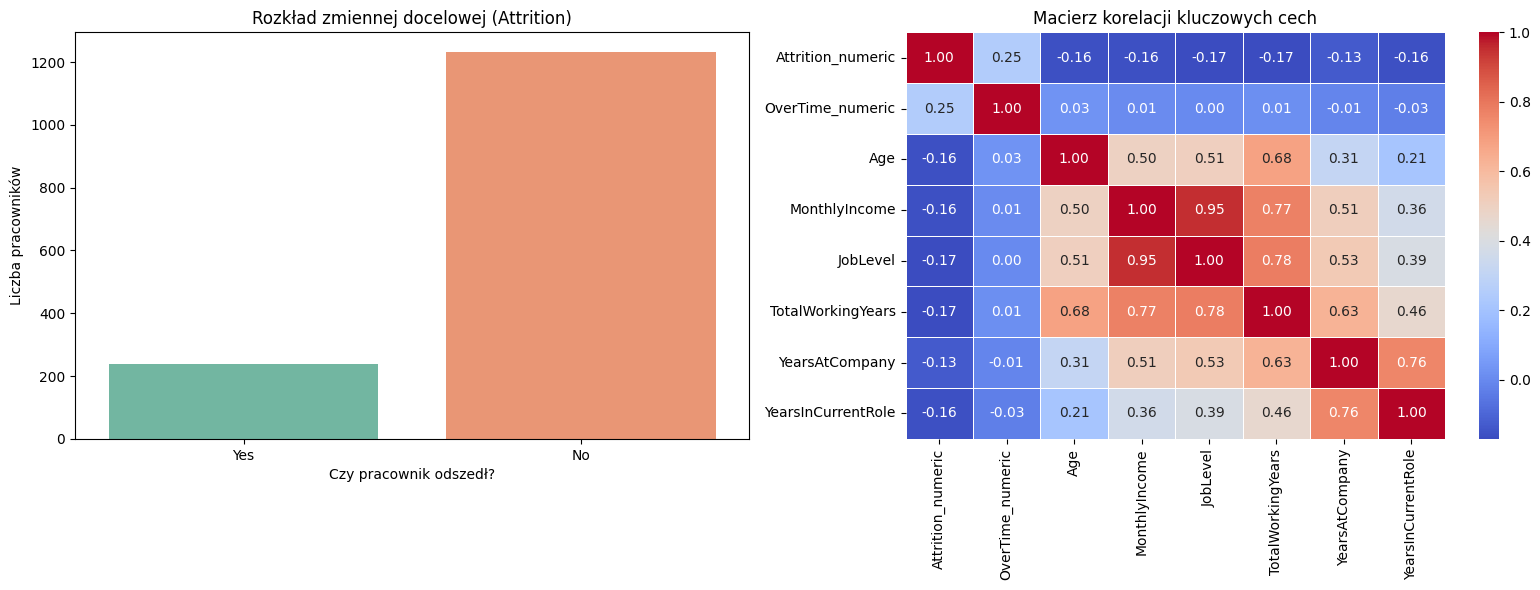

In [8]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Rozkład zmiennej docelowej (Attrition)')
plt.xlabel('Czy pracownik odszedł?')
plt.ylabel('Liczba pracowników')

plt.subplot(1, 2, 2)
selected_features = ['Attrition_numeric', 'OverTime_numeric', 'Age', 'MonthlyIncome', 
                     'JobLevel', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole']
corr_sub_matrix = df_numeric_analysis[selected_features].corr()
sns.heatmap(corr_sub_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji kluczowych cech')

plt.tight_layout()
plt.show()